# Sanger Sequencing Chromatogram Analysis
# Thomas C. Day
This notebook loads Sanger sequencing ".ab1" files, extracts the DNA sequence, fluorescence traces, and visualizes chromatogram peaks.

Requirements:
- Python
- Biopython
- Matplotlib

Workflow:
1. Install packages
2. Load .ab1 files
3. Extract sequences
4. Plot chromatograms

In [3]:
# Install some necessary packages:
%pip install biopython matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 55.5 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 56.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]
Note: you may need to restart the kernel to use updat

In [1]:
# Import items needed
from Bio import SeqIO
import matplotlib.pyplot as plt
import os

In [2]:
# Get the sanger sequencing directory:
data_dir = "/home1/daythoma/03_Sequencing/data/raw_ab1/30-1305489029_ab1/"

# List files in the directory
ab1_files = [f for f in os.listdir(data_dir) if f.endswith(".ab1")]

print("Found", len(ab1_files), "AB1 files")
print(ab1_files)

Found 12 AB1 files
['AT03759600-Premixed.ab1', 'AT03759592-Premixed.ab1', 'AT03759560-Premixed.ab1', 'AT03759624-Premixed.ab1', 'AT03759568-Premixed.ab1', 'AT03759608-Premixed.ab1', 'AT03759632-Premixed.ab1', 'AT03759647-Premixed.ab1', 'AT03759616-Premixed.ab1', 'AT03759584-Premixed.ab1', 'AT03759639-Premixed.ab1', 'AT03759576-Premixed.ab1']


AT03759616-Premixed.ab1
b'GATC'
22
N
0


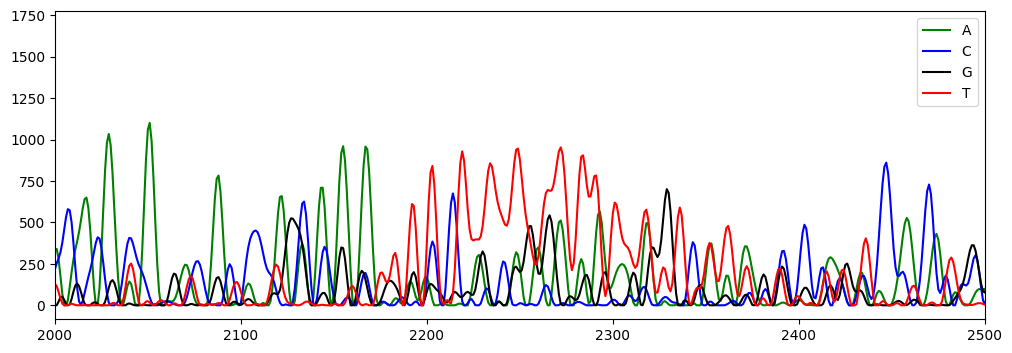

In [11]:
# Load one particular file and inspect it:
file_no = 8;
file_path = os.path.join(data_dir, ab1_files[file_no])
record = SeqIO.read(file_path, "abi")
print(ab1_files[file_no])

# Find the chromatograms:
trace = record.annotations["abif_raw"]

# Print how the channels correspond to the base pairs:
print(trace["FWO_1"])

# Load each channel:
channels = [
    trace["DATA9"],
    trace["DATA10"],
    trace["DATA11"],
    trace["DATA12"]
]

# Assign channels to the proper base pair:
order = trace["FWO_1"].decode()
trace_dict = dict(zip(order, channels))
A = trace_dict["A"]
C = trace_dict["C"]
G = trace_dict["G"]
T = trace_dict["T"]

# Determine base pair assignment:
sequence = str(record.seq)
qualities = record.letter_annotations["phred_quality"]
positions = trace["PLOC2"]
BP = zip(positions, sequence, qualities)
print(positions[1])
print(sequence[1])
print(qualities[1])

# Show:
plt.figure(figsize=(12,4))
plt.plot(trace_dict["A"], label="A",color="Green")
plt.plot(trace_dict["C"], label="C",color="Blue")
plt.plot(trace_dict["G"], label="G",color="Black")
plt.plot(trace_dict["T"], label="T",color="Red")

# Overlay the basepair matches
for pos, base, q in BP:

    peak_height = max(
        A[pos],
        C[pos],
        G[pos],
        T[pos]
    )

    label = f"{base}\n{q}"

    #plt.text(pos, peak_height + 100, label, ha="center", fontsize=8)
    
plt.legend()
plt.xlim([2000,2500])
#plt.ylim([0,300])
plt.show()